# Image Deblurring and Ill-Conditioned Optimization

## Project 2 — Ill-Conditioned Optimization

This project studies image deblurring as an ill-conditioned inverse problem. 
We will examine how blur affects the conditioning of the optimization problem,
demonstrate the effect on a baseline optimizer, and test a regularization-based remedy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

np.random.seed(0)

print("Setup successful!")

Setup successful!


## Experiment 1: From a sharp image to a noisy observation

We create a 128 x 128 grayscale image containing a square, a disk, and two thin bars. Pixel intensities are normalized to the range 0 to 1. We then apply Gaussian blur with a standard deviation of 2 pixels and add Gaussian noise with a standard deviation of 0.03 (3% of the full intensity range) to the blurred image. The blur uses periodic (wrapped) boundaries: pixels beyond one edge continue from the opposite edge.

The original image is the known sharp reference; the blurred, noisy image is the observation that a later deblurring experiment will try to reconstruct.


In [2]:
# Bright shapes on a dark background provide clearly defined edges.
image_size = 128
sharp_image = np.full((image_size, image_size), 0.15, dtype=float)
sharp_image[24:72, 16:56] = 0.85

yy, xx = np.ogrid[:image_size, :image_size]
disk_mask = (xx - 94)**2 + (yy - 44)**2 <= 18**2
sharp_image[disk_mask] = 0.85

# Thin bars make the loss of fine detail easy to see.
sharp_image[88:92, 16:112] = 0.85
sharp_image[104:108, 16:112] = 0.85


In [3]:
blur_sigma = 2.0  # Gaussian blur standard deviation, in pixels.
noise_std = 0.03  # Noise standard deviation in normalized intensity units.

blur_mode = "wrap"  # Periodic boundaries, shared with D1 and D2.
blur_truncate = 4.0  # Same finite Gaussian kernel in every calculation.
blurred_image = gaussian_filter(sharp_image, sigma=blur_sigma, mode=blur_mode, truncate=blur_truncate)

# A local seed gives the same observation whenever this cell is rerun.
rng = np.random.default_rng(0)
noise = rng.normal(loc=0.0, scale=noise_std, size=blurred_image.shape)
noisy_image = blurred_image + noise

print(f"Image size: {image_size} x {image_size}")
print(f"Blur sigma: {blur_sigma:.1f} pixels; noise standard deviation: {noise_std:.2f}")


Image size: 128 x 128
Blur sigma: 2.0 pixels; noise standard deviation: 0.03


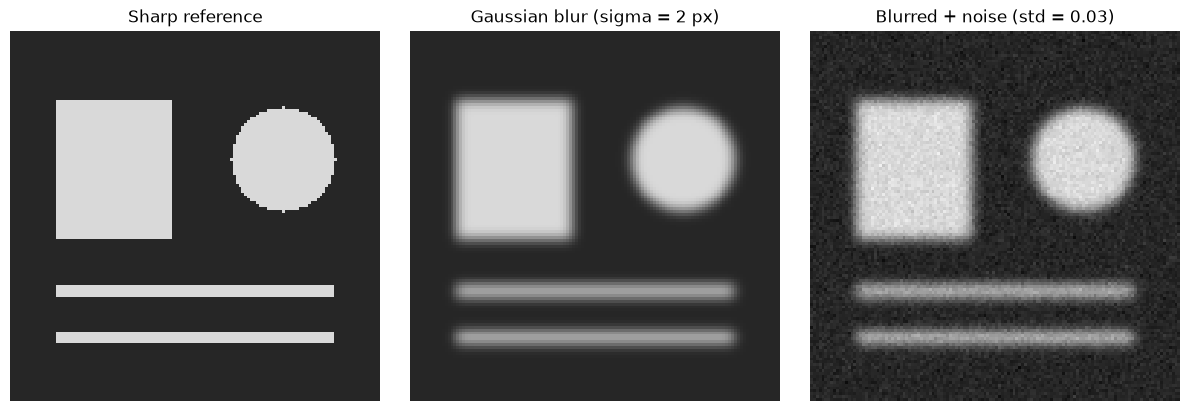

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")

images = [sharp_image, blurred_image, noisy_image]
titles = ["Sharp reference", "Gaussian blur (sigma = 2 px)", "Blurred + noise (std = 0.03)"]

for ax, image, title in zip(axes, images, titles):
    # Fixed limits keep brightness and contrast comparable across all panels.
    ax.imshow(image, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

plt.show()


### What the images show

- **Sharp reference:** The square, disk, and thin bars have abrupt boundaries and uniform interiors.
- **Gaussian blur:** Nearby pixels are averaged, spreading the boundaries into gradual transitions. Corners soften, and the thin bars lose contrast because their width is comparable to the blur scale.
- **Blurred + noise:** Small random intensity changes add visible grain to the blurred image. The edges remain soft; the grain does not restore the original detail.

All three panels use the same grayscale limits (0 to 1), so the differences come from the blur and noise rather than automatic display scaling. Later deblurring methods must recover sharp structure while avoiding amplification of this noise.


## D1: Hessian eigenvalues and spectral condition estimate

For the unregularized least-squares blur problem, let $x$ be the unknown sharp image, $y$ the blurred, noisy observation, and $A$ the blur operator:

$$f(x)=\tfrac12\|Ax-y\|_2^2, \qquad H=\nabla^2 f=A^T A.$$

The Hessian depends on the blur, not on the particular image or noise realization. We use the **same 128 x 128 grid, Gaussian width, periodic boundaries (`mode="wrap"`), and kernel truncation at four standard deviations** as Experiment 1. The earlier reflected-boundary version has been replaced consistently with periodic blur; the numerical values below describe this periodic model.

Gaussian blur is separable: if $B$ blurs one image axis, then the blurred image is $B X B^T$. Thus $A=B\otimes B$ and $H=(B^T B)\otimes(B^T B)$. If $s_i$ are the singular values of $B$, the Hessian eigenvalues are $s_i^2 s_j^2$.

We estimate all 16,384 eigenvalues from the 128 x 128 factor, without forming the large Hessian or clipping its tiny eigenvalues. The reported ratio $\lambda_{\max}/\lambda_{\min}$ is a **spectral estimate of $\kappa_2(H)$**, rather than a reliably resolved condition number of an explicitly assembled float64 Hessian when the ratio is extremely large.


In [5]:
# Reuse the periodic filter settings from Experiment 1.
assert blur_mode == "wrap", "The periodic Jacobi argument requires wrapped boundaries."
assert sharp_image.shape == (image_size, image_size)


def blur_axis_matrix(size, sigma):
    """Column j is the blur of a unit impulse at pixel j along one axis."""
    return gaussian_filter(
        np.eye(size, dtype=float), sigma=(float(sigma), 0.0),
        mode=blur_mode, truncate=blur_truncate,
    )


def hessian_spectrum_from_factor(factor):
    """Spectrum of (factor.T @ factor) tensor (factor.T @ factor)."""
    singular_values = np.linalg.svd(factor, compute_uv=False)
    factor_tolerance = np.finfo(float).eps * factor.shape[0] * singular_values[0]
    if singular_values[-1] <= factor_tolerance:
        raise ValueError("Blur factor is numerically rank deficient; a finite condition estimate is unreliable.")
    eigenvalues = np.sort(np.outer(singular_values**2, singular_values**2).ravel())[::-1]
    condition = eigenvalues[0] / eigenvalues[-1]
    return eigenvalues, condition


B = blur_axis_matrix(image_size, blur_sigma)

# Check both the actual image and a random image that exercises the boundaries.
np.testing.assert_allclose(B @ sharp_image @ B.T, blurred_image, rtol=1e-13, atol=1e-14)
operator_probe = np.random.default_rng(1).normal(size=sharp_image.shape)
probe_blur = gaussian_filter(operator_probe, sigma=blur_sigma, mode=blur_mode, truncate=blur_truncate)
probe_error = np.max(np.abs(B @ operator_probe @ B.T - probe_blur))
np.testing.assert_allclose(B @ operator_probe @ B.T, probe_blur, rtol=1e-13, atol=1e-14)
print(f"Operator matches Experiment 1; random-image maximum difference: {probe_error:.2e}")


Operator matches Experiment 1; random-image maximum difference: 1.94e-16


Hessian size: 16,384 x 16,384
Periodic blur width: sigma = 2 pixels
Estimated largest eigenvalue: 1.000e+00
Estimated smallest eigenvalue: 4.401e-23
Spectral estimate of cond(H): 2.272e+22
float64 epsilon: 2.220e-16; inverse epsilon: 4.504e+15
Estimated eigenvalues below eps * largest eigenvalue: 2,693 / 16,384
The smallest curvatures are unresolved at full-Hessian float64 precision; the large ratio is a structured spectral estimate.


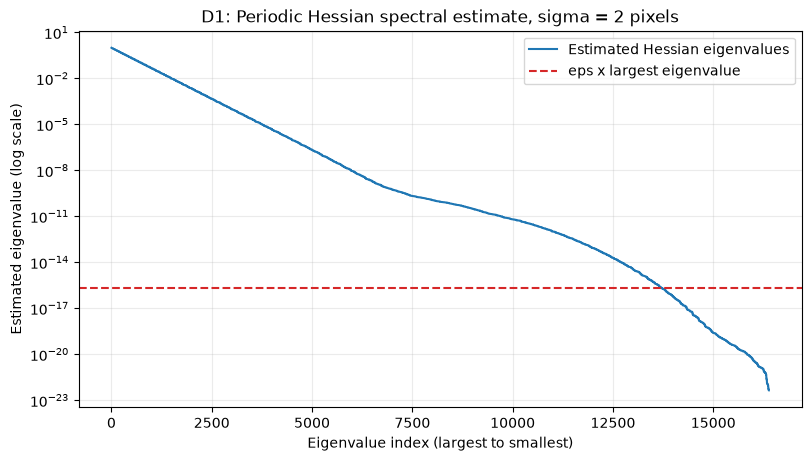

In [6]:
hessian_eigenvalues, hessian_condition = hessian_spectrum_from_factor(B)
float64_epsilon = np.finfo(float).eps
hessian_roundoff_scale = float64_epsilon * hessian_eigenvalues[0]
below_roundoff = np.count_nonzero(hessian_eigenvalues < hessian_roundoff_scale)

print(f"Hessian size: {image_size**2:,} x {image_size**2:,}")
print(f"Periodic blur width: sigma = {blur_sigma:g} pixels")
print(f"Estimated largest eigenvalue: {hessian_eigenvalues[0]:.3e}")
print(f"Estimated smallest eigenvalue: {hessian_eigenvalues[-1]:.3e}")
print(f"Spectral estimate of cond(H): {hessian_condition:.3e}")
print(f"float64 epsilon: {float64_epsilon:.3e}; inverse epsilon: {1 / float64_epsilon:.3e}")
print(f"Estimated eigenvalues below eps * largest eigenvalue: {below_roundoff:,} / {hessian_eigenvalues.size:,}")
print("The smallest curvatures are unresolved at full-Hessian float64 precision; the large ratio is a structured spectral estimate.")

fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.semilogy(np.arange(1, hessian_eigenvalues.size + 1), hessian_eigenvalues, label="Estimated Hessian eigenvalues")
ax.axhline(hessian_roundoff_scale, color="tab:red", linestyle="--", label="eps x largest eigenvalue")
ax.set_xlabel("Eigenvalue index (largest to smallest)")
ax.set_ylabel("Estimated eigenvalue (log scale)")
ax.set_title(f"D1: Periodic Hessian spectral estimate, sigma = {blur_sigma:g} pixels")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
plt.show()


### Reading D1: what the estimate means

Large eigenvalues describe image patterns that still affect the blurred observation strongly. Tiny eigenvalues describe patterns, often fine detail, that blur almost removes. Recovering those weak patterns is sensitive to noise.

At the current periodic blur width of 2 pixels, the estimated eigenvalues range from about 1 to $4.40\times10^{-23}$. Their ratio, about $2.27\times10^{22}$, is a **spectral condition estimate** that signals severe ill-conditioning. It is not a condition number whose digits are certified by a direct float64 Hessian calculation.

Float64 machine epsilon is about $2.22\times10^{-16}$. When a Hessian eigenvalue is far below $\epsilon\lambda_{\max}$, rounding in an explicitly formed Hessian or an ordinary dense eigensolver can overwhelm it. Here 2,693 estimated eigenvalues lie below that reference line. The reciprocal $1/\epsilon\approx4.50\times10^{15}$ is a useful caution scale for direct Hessian calculations, not a universal upper limit on structured spectral estimates.

The separable calculation avoids forming $H$: its one-axis singular values are still above their own rounding scale, so it can estimate attenuation below the full-Hessian reference line. This does not recover trustworthy precision in the assembled Hessian, certify all printed digits, or prove an exactly zero eigenvalue. The dashed line is a precision reference, not a cutoff applied to the spectrum.


## D2: Blur width and Jacobi scaling for periodic blur

We hold the grid and periodic filter settings fixed and vary only the Gaussian standard deviation. A width of zero is the no-blur reference. The plotted condition numbers are **spectral estimates**, with the same floating-point caveat as D1.

Symmetric Jacobi scaling uses

$$D=\operatorname{diag}(H), \qquad H_J=D^{-1/2} H D^{-1/2}.$$

For periodic convolution, every column of $A$ is a circular shift of the same blur kernel. Every column therefore has the same squared norm, so every diagonal entry of $H=A^T A$ equals the same positive constant $c$. Consequently,

$$D=cI, \qquad H_J=H/c, \qquad \kappa_2(H_J)=\kappa_2(H).$$

All eigenvalues change by the same factor, so **Jacobi scaling leaves the condition number unchanged in exact arithmetic**. If the blur were exactly singular, scalar scaling would also leave it singular.

We still compute the two estimates separately to show numerical effects. For $G=B^T B$, let $d_j=G_{jj}=\sum_i B_{ij}^2$. Periodicity makes $d_j=d$ constant and $c=d^2$. The scaled factor $C=B\operatorname{diag}(d^{-1/2})$ supplies the estimated spectrum of $H_J$ through the same separable calculation as D1. The code checks that the diagonal is constant to rounding accuracy.


In [7]:
blur_widths = np.array([0.0, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0, 3.5, 4.0])
blur_widths = np.unique(np.append(blur_widths, blur_sigma))
raw_conditions = []
jacobi_conditions = []
diagonal_relative_spreads = []

for sigma in blur_widths:
    blur_factor = blur_axis_matrix(image_size, sigma)
    reference_blur = gaussian_filter(operator_probe, sigma=sigma, mode=blur_mode, truncate=blur_truncate)
    np.testing.assert_allclose(blur_factor @ operator_probe @ blur_factor.T, reference_blur, rtol=1e-13, atol=1e-14)

    _, raw_condition = hessian_spectrum_from_factor(blur_factor)
    diagonal_1d = np.sum(blur_factor**2, axis=0)
    # Circular shifts have equal column norms: Jacobi is a scalar in exact arithmetic.
    np.testing.assert_allclose(diagonal_1d, diagonal_1d[0], rtol=1e-13, atol=1e-15)
    diagonal_relative_spreads.append(np.ptp(diagonal_1d) / np.mean(diagonal_1d))
    jacobi_factor = blur_factor / np.sqrt(diagonal_1d)[None, :]
    _, jacobi_condition = hessian_spectrum_from_factor(jacobi_factor)
    raw_conditions.append(raw_condition)
    jacobi_conditions.append(jacobi_condition)

raw_conditions = np.array(raw_conditions)
jacobi_conditions = np.array(jacobi_conditions)
# Differences are numerical deviations from exact invariance, not scaling benefits.
jacobi_numerical_difference_pct = 100 * (jacobi_conditions / raw_conditions - 1)

print("Condition numbers below are spectral estimates, not certified full-Hessian float64 measurements.")
print(f"{'sigma (px)':>10} {'estimate H':>15} {'estimate H_J':>15} {'numerical diff %':>18}")
for sigma, raw, scaled, difference in zip(blur_widths, raw_conditions, jacobi_conditions, jacobi_numerical_difference_pct):
    print(f"{sigma:10.2f} {raw:15.3e} {scaled:15.3e} {difference:18.3e}")

original_index = np.flatnonzero(blur_widths == blur_sigma)[0]
original_jacobi_condition = jacobi_conditions[original_index]
print(f"\nAt the original sigma = {blur_sigma:g} px:")
print(f"Raw spectral estimate: {hessian_condition:.3e}; Jacobi spectral estimate: {original_jacobi_condition:.3e}")
print(f"Maximum relative spread of the one-axis Hessian diagonal: {max(diagonal_relative_spreads):.3e}")
print("Exact-arithmetic Jacobi condition number: unchanged. Plotted deviations are floating-point effects.")


Condition numbers below are spectral estimates, not certified full-Hessian float64 measurements.
sigma (px)      estimate H    estimate H_J   numerical diff %
      0.00       1.000e+00       1.000e+00          0.000e+00
      0.50       9.199e+00       9.199e+00         -1.110e-13
      0.75       4.150e+03       4.150e+03         -6.661e-14
      1.00       2.334e+07       2.334e+07         -1.454e-12
      1.25       1.595e+12       1.595e+12         -3.224e-11
      1.50       4.023e+17       4.023e+17          1.512e-11
      1.75       1.543e+23       1.543e+23          1.420e-09
      2.00       2.272e+22       2.272e+22          6.014e-09
      2.25       7.331e+24       7.331e+24          5.161e-10
      2.50       1.812e+25       1.812e+25          1.987e-08
      3.00       1.771e+21       1.771e+21         -1.069e-09
      3.50       2.691e+23       2.691e+23          6.748e-10
      4.00       1.807e+33       1.807e+33          1.356e-06

At the original sigma = 2 px:
Raw 

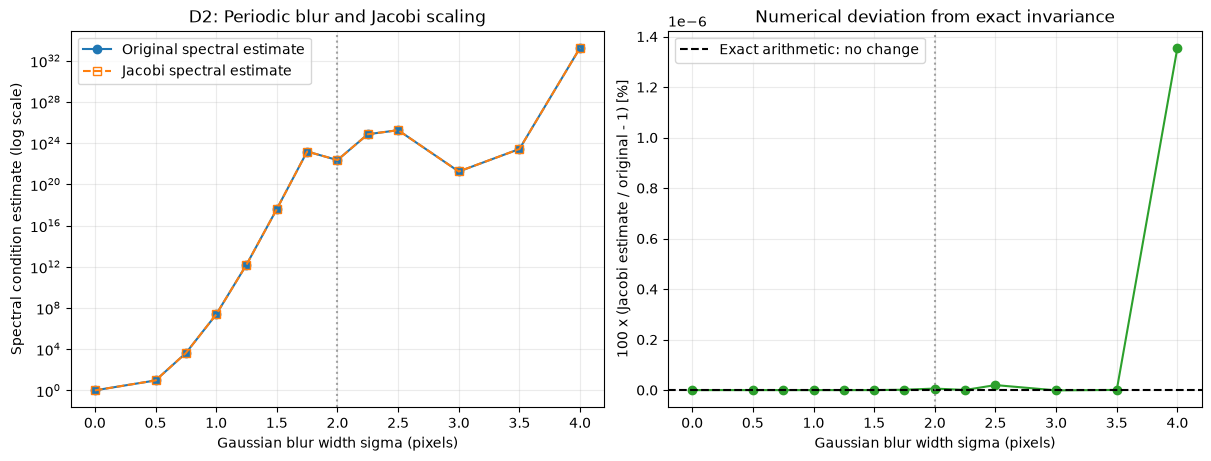

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

axes[0].semilogy(blur_widths, raw_conditions, "o-", label="Original spectral estimate")
axes[0].semilogy(blur_widths, jacobi_conditions, "s--", markerfacecolor="none", label="Jacobi spectral estimate")
axes[0].set_xlabel("Gaussian blur width sigma (pixels)")
axes[0].set_ylabel("Spectral condition estimate (log scale)")
axes[0].set_title("D2: Periodic blur and Jacobi scaling")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(blur_widths, jacobi_numerical_difference_pct, "o-", color="tab:green")
axes[1].axhline(0.0, color="black", linestyle="--", label="Exact arithmetic: no change")
axes[1].set_xlabel("Gaussian blur width sigma (pixels)")
axes[1].set_ylabel("100 x (Jacobi estimate / original - 1) [%]")
axes[1].set_title("Numerical deviation from exact invariance")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

for ax in axes:
    ax.axvline(blur_sigma, color="tab:gray", linestyle=":", alpha=0.7)
plt.show()


### Reading D2: unchanged conditioning in exact arithmetic

With no blur, the Hessian is the identity and the condition number is 1. Wider blur usually suppresses more fine detail and makes recovery harder. The spectral estimates need not rise monotonically: this finite, sampled Gaussian kernel is truncated at four standard deviations, and its weakest response among the discrete periodic frequencies can change sharply as the width changes. Extremely large estimates also require the floating-point caution described in D1.

The original and Jacobi spectral estimates overlap. At the current width of 2 pixels, both are about $2.27\times10^{22}$. For this periodic blur, **the exact condition numbers are identical at every width**, because Jacobi merely multiplies the whole Hessian by a scalar. It cannot reduce the ratio between the strongest and weakest curvatures.

The second plot magnifies the small deviations between separately computed estimates. These come from rounding while normalizing the factors and recomputing their singular values; tiny singular values can amplify relative numerical differences. Positive and negative deviations should not be interpreted as genuine worsening or improvement from Jacobi scaling. The exact-arithmetic reference is zero.

In plain language, all pixels already have the same scale in a periodic blur. Rescaling them equally cannot recover detail removed by smoothing. A useful later remedy must address weak image patterns and noise, such as regularization.

Sources: [SciPy Gaussian filter boundary modes](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html), [Jacobi preconditioning](https://netlib.org/linalg/old_html_templates/section2.7.2.html), and [LAPACK singular-value error bounds](https://www.netlib.org/lapack/lug/node97.html).
